In [2]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Proceso completado. Se han procesado 8185 fechas.
Imagen guardada en: ../img/01_limpieza_y_estacionalidad.png


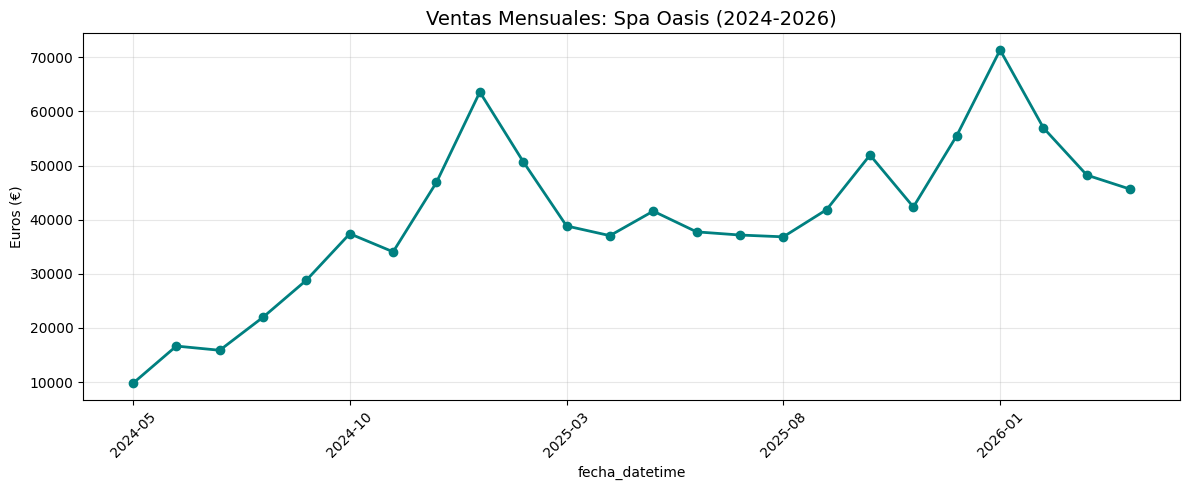

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#CARGA DE DATOS
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

#FUNCIÓN DE LIMPIEZA DE NOMBRES
def limpiar_nombres_columnas(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('¿', '').str.replace('?', '')
                  .str.replace('.', '').str.replace('á', 'a').str.replace('é', 'e')
                  .str.replace('í', 'i').str.replace('ó', 'o').str.replace('ú', 'u'))
    return df

df_ventas = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

#LIMPIEZA MONETARIA
def limpiar_moneda(valor):
    if isinstance(valor, str):
        valor = valor.replace('€', '').replace('.', '').replace(',', '.').strip()
    return pd.to_numeric(valor, errors='coerce')

#Aplicamos limpieza monetaria
col_dinero_reservas = [c for c in df_reservas.columns if 'total' in c or 'pagado' in c][0]
df_ventas['neto'] = df_ventas['neto'].apply(limpiar_moneda)
df_reservas['total_a_recibir'] = df_reservas[col_dinero_reservas].apply(limpiar_moneda)

#TRATAMIENTO DE FECHAS
# Localizamos la columna de fecha en ventas
col_fecha_ventas = [c for c in df_ventas.columns if 'creado' in c or 'fecha' in c][0]

#Limpiamos el texto " a las " antes de convertir
df_ventas['fecha_limpia'] = df_ventas[col_fecha_ventas].astype(str).str.replace(' a las ', ' ', regex=False)
df_ventas['fecha_datetime'] = pd.to_datetime(df_ventas['fecha_limpia'], errors='coerce')

#TRATAMIENTO GEOGRÁFICO Y OTROS
col_cp = [c for c in df_ventas.columns if 'codigo' in c or 'postal' in c][0]
df_ventas['codigo_postal'] = df_ventas[col_cp].fillna('00000').astype(str)

col_repro = [c for c in df_ventas.columns if 'repro' in c][0]
mapeo_bool = {'Sí': 1, 'No': 0, 'S': 1, 'N': 0, 'Si': 1, 'Yes': 1}
df_ventas['reprogramado'] = df_ventas[col_repro].map(mapeo_bool).fillna(0).astype(int)

#GENERACIÓN DEL GRÁFICO DE ESTACIONALIDAD
total_fechas = df_ventas['fecha_datetime'].notnull().sum()

if total_fechas > 0:
    df_ventas_clean = df_ventas.dropna(subset=['fecha_datetime', 'neto'])
    
    # Agrupamos por mes
    ventas_mensuales = df_ventas_clean.groupby(df_ventas_clean['fecha_datetime'].dt.to_period('M'))['neto'].sum()
    ventas_mensuales.index = ventas_mensuales.index.astype(str)
    
    plt.figure(figsize=(12, 5))
    ventas_mensuales.plot(kind='line', marker='o', color='teal', linewidth=2)
    
    plt.title('Ventas Mensuales: Spa Oasis (2024-2026)', fontsize=14)
    plt.ylabel('Euros (€)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    #GUARDADO AUTOMÁTICO
    if not os.path.exists('../img'):
        os.makedirs('../img')
    
    plt.savefig('../img/01_limpieza_y_estacionalidad.png')
    print(f"Proceso completado. Se han procesado {total_fechas} fechas.")
    print("Imagen guardada en: ../img/01_limpieza_y_estacionalidad.png")
    
    plt.show()
else:
    print(f"Error: No se pudieron procesar las fechas de la columna {col_fecha_ventas}")